# **1**

---
## **Анализ дорожно‑транспортных происшествий в России**

<div style="background-color: #C3B1E1; padding: 10px; border-radius: 4px;">

**Инсайты за 1 минуту**

- Чаще всего в ДТП участвуют 2–3 участника; при росте числа участников заметно растёт и число пострадавших.
- Основные категории ДТП чаще происходят в обычных условиях — при ясной и пасмурной погоде днём, на сухой дороге (иногда с плохо различимой разметкой).
- Есть несоответствия между `injured_count` и `health_status`, поэтому важно улучшить, как фиксируются пострадавшие в данных, и отдельно проанализировать места, где чаще происходят ДТП с большим числом участников.

    </div>


[Сразу к сделанной работе и выводам](#6)

## **1.1**

### **Цель и задачи проекта**

<font color='#777778'>

**Цель проекта**

Изучить аварийность на дорогах Кировской области на основе данных проекта «Карты ДТП», выявить ключевые факторы, связанные с числом участников и тяжестью последствий аварий, и подготовить рекомендации для заказчика по повышению безопасности дорожного движения.
</font>

<font color='#777778'>

**Задачи проекта**

- Проанализировать распределение числа участников ДТП, выявить аномальные значения и выбросы, определить наиболее типичное число участников и при необходимости проверить распределения других признаков.  
- Сформулировать гипотезы о высоких корреляциях между столбцами датасета `Kirovskaya_oblast.csv` и проверить их статистическими методами.  
- Исследовать взаимосвязь категорий аварий и погодных условий, выделить наиболее рискованные сочетания.  
- Построить процентную разбивку аварий по видам освещённости отдельно для мужчин и женщин, оценить различия между группами.  
- Сравнить аварии без пострадавших с авариями с одним и более пострадавшими, определить ключевые отличающие факторы.  
- Сформулировать общий вывод о связи аварийности с факторами среды и характеристиками участников и подготовить практические рекомендации для заказчика.  

</font>

[Вперёд к содержанию](#2)


## **1.2**

## **Описание данных**

<font color='#777778'>
    
Датасет **`Kirovskaya_oblast.csv`** содержит информацию о ДТП в Кировской области:

* `geometry.coordinates` — координаты ДТП;
  
* `id` — идентификатор ДТП;

* `properties.tags` — тег происшествия;

* `properties.light` — освещённость;

* `properties.point.lat` — широта;

* `properties.point.long` — долгота;

* `properties.nearby` — ближайшие объекты;

* `properties.region` — регион;

* `properties.scheme` — схема ДТП;

* `properties.address` — ближайший адрес;

* `properties.weather` — погода;

* `properties.category` — категория ДТП;

* `properties.datetime` — дата и время ДТП;

* `properties.injured_count` — число пострадавших;

* `properties.parent_region` — область;

* `properties.road_conditions` — состояние покрытия;

* `properties.participants_count` — число участников;

* `properties.participant_categories` — категории участников.

**`Kirovskaya_oblast_participiants.csv`** хранит сведения об участниках:

* `role` — роль;

* `gender` — пол;

* `violations` — какие правила дорожного движения были нарушены конкретным участником;

* `health_status` — состояние здоровья после ДТП;

* `years_of_driving_experience` — число лет опыта;

* `id` — идентификатор ДТП.
</font>

[Вперёд к содержанию](#2)

# **2**

---
## **Содержание**

- [1. Кейс спринта](#1)  
  - [1.1 Цели и задачи проекта](#1.1)  
  - [1.2 Описание данных](#1.2)  
- [2. Содержание](#2)
- [3. Загрузка данных и знакомство с ними](#3-bullet)  
- [4. Предобработка данных](#4-bullet)   
- [5. Исследование данных](#5-bullet)  
  - [5.1 Распределение числа участников ДТП, выбросы и типичное значение](#5.1)  
  - [5.2 Предположение о высоких корреляциях между признаками и проверка гипотезы](#5.2)  
  - [5.3 Связь категорий аварий с погодными условиями](#5.3)  
  - [5.4 Процентная разбивка аварий по видам освещённости с учётом пола участника](#5.4)  
  - [5.5 Отличия аварий без пострадавших и с пострадавшими](#5.5)  
- [6. Итоговый вывод и рекомендации](#6) 
  - [6.1 Общий обзор проделанной работы](#6.1)  
  - [6.2 Ключевые выводы](#6.2)  
  - [6.3 Рекомендации для заказчика](#6.3) 

# **3**

---
## **Загрузка данных и знакомство с ними**

<font color='#777778'>Для начала работы импортируем основные библиотеки для анализа данных и визуализации:
- `pandas`;
- `numpy`;
- `matplotlib`;
- `seaborn`.

Дополнительно устанавливаем и подключаем вспомогательные библиотеки:  
- `phik` — для расчёта матрицы корреляций (в том числе для категориальных признаков);  
- `missingno` — для наглядной визуализации пропусков в данных.
</font>


In [1]:
!pip install phik

In [2]:
%pip install missingno

Note: you may need to restart the kernel to use updated packages.


In [3]:
import phik
from phik.report import plot_correlation_matrix

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns

In [5]:
# для красивых графиков в ноутбуке
sns.set(style='white')
plt.rcParams['figure.figsize'] = (10, 6)

<font color='#777778'>Загрузили данные о ДТП в Кировской области.</font>

In [6]:
# Данные по ДТП
kirov = pd.read_csv(
    'https://code.s3.yandex.net/datasets/Kirovskaya_oblast.csv',
    low_memory=False
)
kirov.columns = kirov.columns.str.replace('properties\.', '', regex=True)  # убираем приставку

# Данные по участникам
kirov_part = pd.read_csv(
    'https://code.s3.yandex.net/datasets/Kirovskaya_oblast_participiants.csv',
    low_memory=False
)
kirov_part.columns = kirov_part.columns.str.replace('properties\.', '', regex=True)

In [7]:
for df in [kirov, kirov_part]:
    display(df.shape)

(14517, 18)

(31235, 6)

In [8]:
kirov.info()
kirov.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14517 entries, 0 to 14516
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   geometry.coordinates    14517 non-null  object 
 1   id                      14517 non-null  int64  
 2   tags                    14517 non-null  object 
 3   light                   14517 non-null  object 
 4   point.lat               14485 non-null  float64
 5   point.long              14485 non-null  float64
 6   nearby                  14517 non-null  object 
 7   region                  14517 non-null  object 
 8   scheme                  13380 non-null  float64
 9   address                 13843 non-null  object 
 10  weather                 14517 non-null  object 
 11  category                14517 non-null  object 
 12  datetime                14517 non-null  object 
 13  injured_count           14517 non-null  int64  
 14  parent_region           14517 non-null

,geometry.coordinates,id,tags,light,point.lat,point.long,nearby,region,scheme,address,weather,category,datetime,injured_count,parent_region,road_conditions,participants_count,participant_categories
0,"[47.875603, 57.24379]",1983180,Дорожно-транспортные происшествия,Светлое время суток,57.243790,47.875603,[],Яранский район,600.0,Р-176 Вятка Чебоксары - Йошкар-Ола - Киров - С...,['Дождь'],Опрокидывание,2017-07-01 18:00:00,1,Кировская область,['Мокрое'],3,['Все участники']
1,"[47.87903, 57.304807]",2889433,Дорожно-транспортные происшествия,Светлое время суток,57.304807,47.879030,"['Административные здания', 'Нерегулируемый пе...",Яранский район,710.0,"г Яранск, ул Кирова, 10",['Ясно'],Наезд на пешехода,2023-09-12 17:10:00,1,Кировская область,"['Сухое', 'Отсутствие, плохая различимость гор...",2,"['Все участники', 'Пешеходы']"
2,"[47.840781, 57.297156]",2591208,Дорожно-транспортные происшествия,Сумерки,57.297156,47.840781,"['Жилые дома индивидуальной застройки', 'Нерег...",Яранский район,NaN,"г Яранск, ул Чапаева, 80",['Пасмурно'],Съезд с дороги,2021-07-02 21:25:00,1,Кировская область,['Мокрое'],1,['Все участники']
3,"[47.834365, 57.244775]",2577639,Дорожно-транспортные происшествия,Светлое время суток,57.244775,47.834365,['Жилые дома индивидуальной застройки'],Яранский район,200.0,"м Знаменка, ул Кирова, 15",['Пасмурно'],Столкновение,2021-05-31 18:55:00,1,Кировская область,['Сухое'],2,"['Все участники', 'Мотоциклисты']"
4,"[47.968197, 57.357738]",1981026,Дорожно-транспортные происшествия,Светлое время суток,57.357738,47.968197,['Нерегулируемый перекрёсток неравнозначных ул...,Яранский район,NaN,"с/п Никольское, Киров-Советск- Яранск - подъез...",['Ясно'],Опрокидывание,2018-05-16 16:25:00,2,Кировская область,"['Сухое', 'Отсутствие, плохая различимость гор...",2,['Все участники']


In [9]:
kirov.sample(3, random_state=42)

,geometry.coordinates,id,tags,light,point.lat,point.long,nearby,region,scheme,address,weather,category,datetime,injured_count,parent_region,road_conditions,participants_count,participant_categories
11765,"[49.326532, 58.956338]",1988622,Дорожно-транспортные происшествия,Светлое время суток,58.956338,49.326532,[],Юрьянский район,10.0,Р-176 Вятка Чебоксары - Йошкар-Ола - Киров - С...,"['Снегопад', 'Метель']",Столкновение,2019-02-05 15:10:00,1,Кировская область,['Обработанное противогололедными материалами'],4,['Все участники']
836,"[48.928986, 57.595765]",2591843,Дорожно-транспортные происшествия,"В темное время суток, освещение отсутствует",57.595765,48.928986,"['Мост', 'Остановка общественного транспорта',...",Советский район,820.0,"г Советск, Киров - Советск - Яранск, 133 км",['Дождь'],Наезд на пешехода,2021-07-04 01:34:00,1,Кировская область,['Мокрое'],2,"['Все участники', 'Пешеходы']"
1475,"[49.254037, 58.469716]",3011739,Дорожно-транспортные происшествия,Светлое время суток,58.469716,49.254037,['Нерегулируемый перекрёсток неравнозначных ул...,Оричевский район,210.0,"тер Стрижевское городское поселение, ул Кирова...",['Ясно'],Столкновение,2024-08-26 15:55:00,2,Кировская область,"['Сухое', 'Отсутствие, плохая различимость гор...",3,"['Все участники', 'Мотоциклисты']"


In [10]:
kirov_part.info()
kirov_part.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31235 entries, 0 to 31234
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   role                         31235 non-null  object 
 1   gender                       30387 non-null  object 
 2   violations                   31235 non-null  object 
 3   health_status                31135 non-null  object 
 4   years_of_driving_experience  16909 non-null  float64
 5   id                           31235 non-null  int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 1.4+ MB


,role,gender,violations,health_status,years_of_driving_experience,id
0,Водитель,Мужской,['Несоответствие скорости конкретным условиям ...,"Раненый, находящийся (находившийся) на амбулат...",26.0,1983180
1,Водитель,Мужской,[],Не пострадал,34.0,2889433
2,Пассажир,Мужской,[],"Раненый, находящийся (находившийся) на амбула...",NaN,2591208
3,Пассажир,Мужской,[],"Раненый, находящийся (находившийся) на амбула...",NaN,2591208
4,Водитель,Мужской,[],Не пострадал,27.0,2577639


In [11]:
kirov_part.sample(3, random_state=42)

,role,gender,violations,health_status,years_of_driving_experience,id
13133,Пассажир,Женский,['Нарушение правил пользования общественным тр...,"Раненый, находящийся (находившийся) на амбула...",NaN,2623943
7794,Водитель,Мужской,['Нарушение правил проезда пешеходного перехода'],Не пострадал,34.0,2741670
26324,Водитель,Женский,['Несоответствие скорости конкретным условиям ...,Получил телесные повреждения с показанием к ле...,12.0,1983172


<font color='#777778'>

**Промежуточные выводы по структуре kirov и kirov_part**

- Таблица `kirov` содержит 14 517 строк и 18 столбцов: описывает сами ДТП (место, время, погодные и дорожные условия, категории ДТП, число пострадавших и участников). 
- В `kirov` есть немного пропусков в координатах (`point.lat`, `point.long`), схеме (`scheme`) и адресах (`address`), остальные признаки заполнены полностью. 
- Таблица `kirov_part` содержит 31 235 строк и 6 столбцов: хранит данные об участниках ДТП (роль, пол, нарушения, состояние здоровья, стаж и `id` для связи с основной таблицей).  
- В `kirov_part` заметная доля пропусков в поле `years_of_driving_experience`, единичные пропуски в `gender` и `health_status`, что нужно учесть при дальнейшей предобработке и анализе.

</font>

[Назад к содержанию](#2)

# **4**

---
## **Предобработка данных**

<font color='#777778'>Смотрим на заголовки столбцов.
</font>

In [12]:
dfs = {
    'kirov': kirov,
    'kirov_part': kirov_part,
}

for name, df in dfs.items():
    print(f'Колонки в {name}:')
    display(pd.DataFrame(df.columns, columns=['column_name']))

Колонки в kirov:


,column_name
0,geometry.coordinates
1,id
2,tags
3,light
4,point.lat
5,point.long
6,nearby
7,region
8,scheme
9,address


Колонки в kirov_part:


,column_name
0,role
1,gender
2,violations
3,health_status
4,years_of_driving_experience
5,id


In [13]:
kirov = kirov.rename(columns={
    'geometry.coordinates': 'geometry_coordinates',
    'point.lat': 'lat',
    'point.long': 'lon',
})

In [14]:
dfs = {
    'kirov': kirov,
    'kirov_part': kirov_part,
}

for name, df in dfs.items():
    print(f'Колонки в {name}:')
    display(pd.DataFrame(df.columns, columns=['column_name']))

Колонки в kirov:


,column_name
0,geometry_coordinates
1,id
2,tags
3,light
4,lat
5,lon
6,nearby
7,region
8,scheme
9,address


Колонки в kirov_part:


,column_name
0,role
1,gender
2,violations
3,health_status
4,years_of_driving_experience
5,id


<font color='#777778'>
    
**Промежуточные выводы по структуре данных**

- В данных ДТП (`kirov`) есть информация о месте, времени, условиях и последствии аварий: координаты, адрес, погода, категория ДТП, состояние дороги, число пострадавших и участников.
- В таблице участников (`kirov_part`) хранятся сведения об отдельных участниках: роль в ДТП, пол, нарушения, состояние здоровья, стаж вождения и идентификатор ДТП (`id`) для связки с основной таблицей.
- Набор колонок в обеих таблицах выглядит логично и позволяет в дальнейшем объединять данные по ДТП и по участникам для более детального анализа.

</font>

[Назад к содержанию](#2)

# **5**

---
## **Исследование данных**

### **5.1**

### **Распределение числа участников ДТП, выбросы и типичное значение**

In [15]:
kirov['participants_count'].describe()

count    14517.000000
mean         2.355721
std          1.004847
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         30.000000
Name: participants_count, dtype: float64

In [16]:
kirov['participants_count'].value_counts().sort_index().reset_index()

,participants_count,count
0,1,1533
1,2,8611
2,3,2929
3,4,909
4,5,353
5,6,109
6,7,44
7,8,9
8,9,9
9,10,5


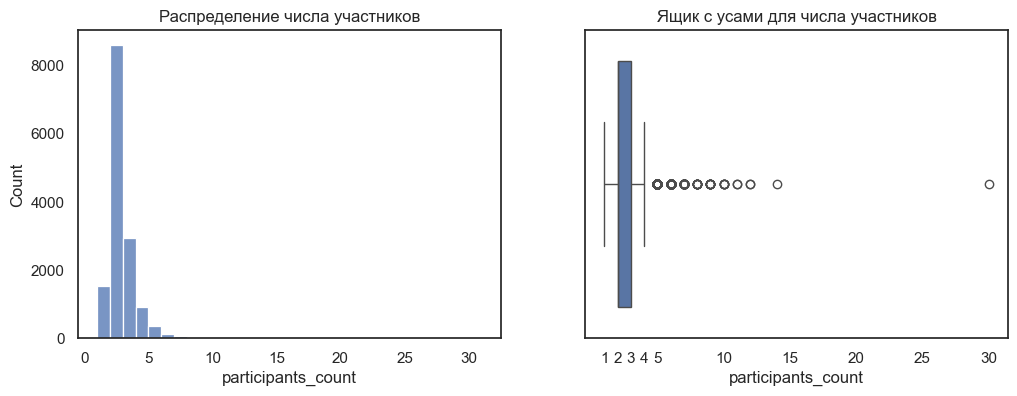

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(kirov['participants_count'], bins=range(1, kirov['participants_count'].max()+2), ax=ax[0])
ax[0].set_title('Распределение числа участников')

sns.boxplot(x=kirov['participants_count'], ax=ax[1])

ticks = list(range(1, 6)) + [10, 15, 20, 25, 30]
ax[1].set_xticks(ticks)
ax[1].set_xticklabels(ticks)

ax[1].set_title('Ящик с усами для числа участников')

plt.show()

In [18]:
# 1. Диапазон значений (отсортированные уникальные)
print('Уникальные значения participants_count (отсортированные):')
unique_vals = np.sort(kirov['participants_count'].unique())
print(unique_vals)

# 2. Подозрительные нули/отрицательные (первые 5 строк)
print('\nСтроки с participants_count <= 0 (первые 5):')
display(kirov[kirov['participants_count'] <= 0].head())

# 3. Потенциальные выбросы (порог настроечный, первые 5 строк)
threshold = 5  # можно менять
print(f'\nСтроки с participants_count > {threshold} (первые 5):')
display(kirov[kirov['participants_count'] > threshold].head())

Уникальные значения participants_count (отсортированные):
[ 1  2  3  4  5  6  7  8  9 10 11 12 14 30]

Строки с participants_count <= 0 (первые 5):


,geometry_coordinates,id,tags,light,lat,lon,nearby,region,scheme,address,weather,category,datetime,injured_count,parent_region,road_conditions,participants_count,participant_categories



Строки с participants_count > 5 (первые 5):


,geometry_coordinates,id,tags,light,lat,lon,nearby,region,scheme,address,weather,category,datetime,injured_count,parent_region,road_conditions,participants_count,participant_categories
30,"[47.858, 57.305]",1982604,Дорожно-транспортные происшествия,"В темное время суток, освещение включено",57.305000,47.858000,"['Жилые дома индивидуальной застройки', 'Остан...",Яранский район,200.0,"г Яранск, ул Лагуновская, 1а",['Ясно'],Столкновение,2018-03-18 18:20:00,6,Кировская область,"['Сухое', 'Отсутствие, плохая различимость гор...",8,['Все участники']
172,"[47.861445, 57.313707]",1981143,Дорожно-транспортные происшествия,Светлое время суток,57.313707,47.861445,['Нерегулируемый перекрёсток неравнозначных ул...,Яранский район,120.0,"г Яранск, Р-176 Вятка Чебоксары - Йошкар-Ола -...",['Пасмурно'],Столкновение,2019-07-13 15:35:00,4,Кировская область,['Отсутствие элементов обустройства остановочн...,6,['Все участники']
315,"[46.894476, 58.318556]",1981875,Дорожно-транспортные происшествия,Светлое время суток,58.318556,46.894476,[],Шабалинский район,600.0,"Р-243 Кострома - Шарья - Киров - Пермь, 406 км",['Пасмурно'],Опрокидывание,2019-01-12 10:50:00,5,Кировская область,['Обработанное противогололедными материалами'],6,"['Все участники', 'Дети']"
466,"[49.87279, 57.114222]",1987435,Дорожно-транспортные происшествия,Светлое время суток,57.114222,49.872790,['Нерегулируемый перекрёсток неравнозначных ул...,Уржумский район,610.0,"Уржум - Буйское - Фролята, 1 км",['Ясно'],Наезд на препятствие,2016-08-15 10:10:00,7,Кировская область,['Сухое'],7,"['Все участники', 'Дети']"
475,"[50.2464, 56.9903]",2779303,Дорожно-транспортные происшествия,"В темное время суток, освещение отсутствует",56.990300,50.246400,[],Уржумский район,70.0,"Киров - Малмыж - Вятские Поляны, 212 км",['Пасмурно'],Столкновение,2022-11-08 05:15:00,2,Кировская область,['Мокрое'],7,['Все участники']


In [19]:
q1 = kirov['participants_count'].quantile(0.25)
q3 = kirov['participants_count'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = kirov[(kirov['participants_count'] < lower) | (kirov['participants_count'] > upper)]
outliers.head()

,geometry_coordinates,id,tags,light,lat,lon,nearby,region,scheme,address,weather,category,datetime,injured_count,parent_region,road_conditions,participants_count,participant_categories
24,"[47.8785, 57.0045]",1986882,Дорожно-транспортные происшествия,Светлое время суток,57.004500,47.878500,[],Яранский район,900.0,Р-176 Вятка Чебоксары - Йошкар-Ола - Киров - С...,['Пасмурно'],Наезд на животное,2016-05-27 21:36:00,5,Кировская область,"['Сухое', 'Отсутствие, плохая различимость гор...",5,"['Все участники', 'Дети']"
30,"[47.858, 57.305]",1982604,Дорожно-транспортные происшествия,"В темное время суток, освещение включено",57.305000,47.858000,"['Жилые дома индивидуальной застройки', 'Остан...",Яранский район,200.0,"г Яранск, ул Лагуновская, 1а",['Ясно'],Столкновение,2018-03-18 18:20:00,6,Кировская область,"['Сухое', 'Отсутствие, плохая различимость гор...",8,['Все участники']
39,"[47.964163, 57.069506]",2553468,Дорожно-транспортные происшествия,Светлое время суток,57.069506,47.964163,['Нерегулируемый перекрёсток неравнозначных ул...,Яранский район,NaN,"с/п Шкаланское, Р-176 Вятка Чебоксары - Йошкар...",['Пасмурно'],Столкновение,2021-03-05 12:35:00,3,Кировская область,['Мокрое'],5,"['Все участники', 'Дети']"
50,"[47.9705, 57.095]",1980929,Дорожно-транспортные происшествия,"В темное время суток, освещение отсутствует",57.095000,47.970500,['Нерегулируемый пешеходный переход'],Яранский район,200.0,Р-176 Вятка Чебоксары - Йошкар-Ола - Киров - С...,['Ясно'],Столкновение,2016-03-20 19:15:00,3,Кировская область,['Сухое'],5,"['Все участники', 'Дети']"
125,"[47.929723, 57.360273]",2847770,Дорожно-транспортные происшествия,Светлое время суток,57.360273,47.929723,[],Яранский район,610.0,"Киров - Советск - Яранск, 210 км",['Ясно'],Съезд с дороги,2023-06-27 14:25:00,5,Кировская область,['Сухое'],5,['Все участники']


<font color='#777778'>

**Промежуточные выводы по числу участников ДТП (`participants_count`)**

- Значения признака лежат в диапазоне от 1 до 30 участников, при этом типичный диапазон — 2–3 участника (25-й, 50-й и 75-й процентили равны 2, 2 и 3 соответственно). 
- Среднее значение (≈2.36) немного выше медианы (2), что указывает на правый «хвост» распределения за счёт редких ДТП с большим числом участников.  
- Большинство происшествий приходится на 2 и 3 участника (8611 и 2929 случаев), значения 5 и более встречаются значительно реже, а случаи с 8+ участниками единичны.  
- Максимальное значение 30 участников выглядит как редкое и потенциально аномальное наблюдение, его имеет смысл дополнительно проверить по исходным данным.
</font>

[Назад к содержанию](#2)

### **5.2**

### **Предположение о высоких корреляциях между признаками и проверка гипотезы**

<font color='#777778'>

**Гипотеза**

Предполагаем, что среди числовых признаков сильнее всего связаны показатели масштаба ДТП: число участников (`participants_count`) и число пострадавших (`injured_count`).


</font>

Коэффициент корреляции Пирсона между participants_count и injured_count: 0.727


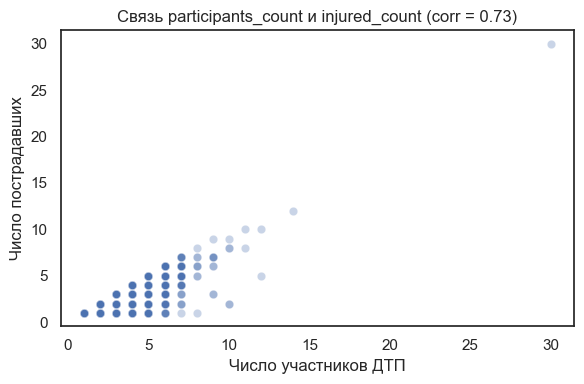

In [20]:
# 1. Считаем корреляцию между числом участников и числом пострадавших
corr_value = kirov['participants_count'].corr(kirov['injured_count'], method='pearson')
print(f'Коэффициент корреляции Пирсона между participants_count и injured_count: {corr_value:.3f}')

# 2. Визуально проверяем связь на scatterplot
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=kirov,
    x='participants_count',
    y='injured_count',
    alpha=0.3
)
plt.title(f'Связь participants_count и injured_count (corr = {corr_value:.2f})')
plt.xlabel('Число участников ДТП')
plt.ylabel('Число пострадавших')
plt.tight_layout()
plt.show()

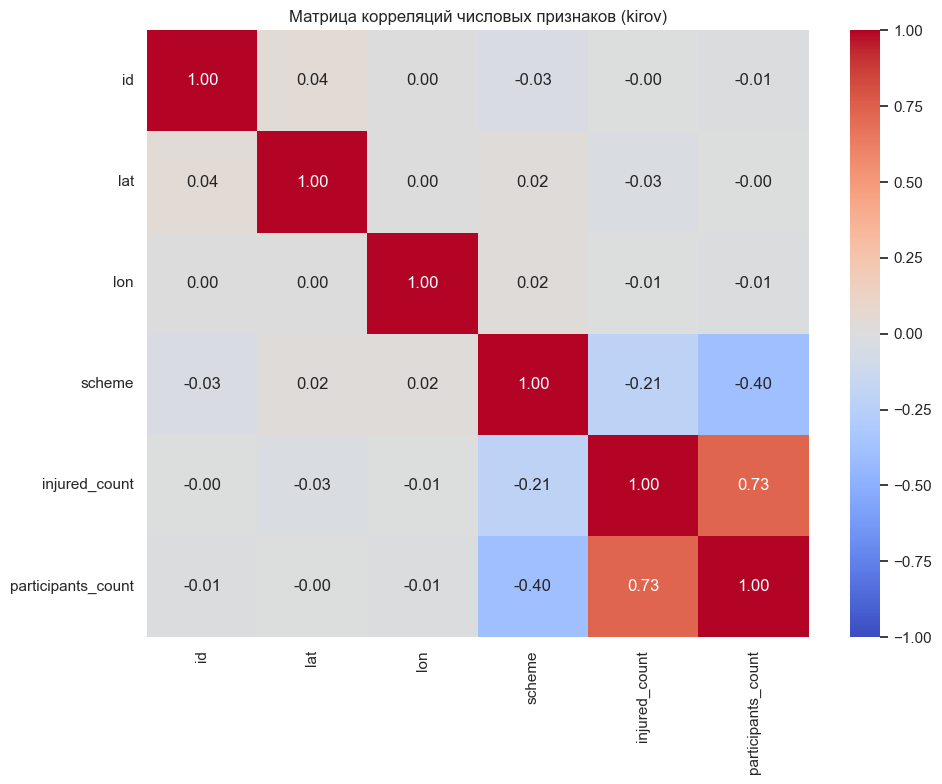

In [21]:
# Берём только числовые столбцы
num_df = kirov.select_dtypes(include='number')

# Матрица корреляций Пирсона
corr_matrix = num_df.corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)
plt.title('Матрица корреляций числовых признаков (kirov)')
plt.tight_layout()
plt.show()

<font color='#777778'>

**Промежуточные выводы по корреляциям**

- Между числом участников ДТП (`participants_count`) и числом пострадавших (`injured_count`) наблюдается сильная положительная линейная связь (corr ≈ 0.73): чем больше участников, тем больше пострадавших в среднем.  
- Связь между схемой ДТП (`scheme`) и числом участников умеренно отрицательная (corr ≈ -0.4), то есть разные типы схем характерны для различного масштаба аварий: одни чаще связаны с большим числом участников, другие — с меньшим.

</font>

[Назад к содержанию](#2)

### **5.3**

### **Связь категорий аварий с погодными условиями**

In [22]:
# Кросс-таблица: количество аварий по категориям и погоде
ct = pd.crosstab(
    kirov['category'],  # категория ДТП
    kirov['weather']    # погодные условия
)

ct_style = (
    ct
    .style
    .background_gradient(cmap='Greens') 
)
display(ct_style)

weather,"['Дождь', 'Снегопад']","['Дождь', 'Туман']",['Дождь'],['Метель'],"['Пасмурно', 'Дождь']","['Пасмурно', 'Метель']","['Пасмурно', 'Снегопад']","['Пасмурно', 'Температура ниже -30С']","['Пасмурно', 'Туман']","['Пасмурно', 'Ураганный ветер']",['Пасмурно'],"['Снегопад', 'Метель']",['Снегопад'],['Туман'],"['Ясно', 'Температура выше +30С']","['Ясно', 'Температура ниже -30С']","['Ясно', 'Туман']",['Ясно']
category,,,,,,,,,,,,,,,,,,
Иной вид ДТП,0,0,2,0,0,0,0,0,0,0,52,0,3,0,1,0,0,71
Наезд на велосипедиста,0,0,17,0,1,0,0,0,0,0,171,0,1,0,2,0,0,397
Наезд на внезапно возникшее препятствие,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,2
Наезд на животное,0,0,4,0,0,0,1,0,0,0,36,0,1,0,0,0,0,47
"Наезд на лицо, не являющееся участником дорожного движения, осуществляющее какую-либо другую деятельность",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3
"Наезд на лицо, не являющееся участником дорожного движения, осуществляющее несение службы",0,0,1,0,0,0,0,0,0,0,7,0,0,0,0,0,0,2
"Наезд на лицо, не являющееся участником дорожного движения, осуществляющее производство работ",0,0,0,0,0,0,0,0,0,0,2,0,1,0,0,0,0,9
Наезд на пешехода,2,1,220,9,36,1,27,2,0,0,2268,4,200,6,14,2,0,1572
Наезд на препятствие,0,0,26,0,2,0,4,0,0,0,300,0,24,2,4,1,0,304


In [23]:
# Доли по строкам: структура типов погоды внутри каждой категории аварий
row_percent = ct.div(ct.sum(axis=1), axis=0) * 100
row_style = (
    row_percent
    .round(1)
    .style
    .background_gradient(cmap='Blues')
    .format('{:.1f}')
)
display(row_style)

weather,"['Дождь', 'Снегопад']","['Дождь', 'Туман']",['Дождь'],['Метель'],"['Пасмурно', 'Дождь']","['Пасмурно', 'Метель']","['Пасмурно', 'Снегопад']","['Пасмурно', 'Температура ниже -30С']","['Пасмурно', 'Туман']","['Пасмурно', 'Ураганный ветер']",['Пасмурно'],"['Снегопад', 'Метель']",['Снегопад'],['Туман'],"['Ясно', 'Температура выше +30С']","['Ясно', 'Температура ниже -30С']","['Ясно', 'Туман']",['Ясно']
category,,,,,,,,,,,,,,,,,,
Иной вид ДТП,0.0,0.0,1.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40.3,0.0,2.3,0.0,0.8,0.0,0.0,55.0
Наезд на велосипедиста,0.0,0.0,2.9,0.0,0.2,0.0,0.0,0.0,0.0,0.0,29.0,0.0,0.2,0.0,0.3,0.0,0.0,67.4
Наезд на внезапно возникшее препятствие,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0
Наезд на животное,0.0,0.0,4.5,0.0,0.0,0.0,1.1,0.0,0.0,0.0,40.4,0.0,1.1,0.0,0.0,0.0,0.0,52.8
"Наезд на лицо, не являющееся участником дорожного движения, осуществляющее какую-либо другую деятельность",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0
"Наезд на лицо, не являющееся участником дорожного движения, осуществляющее несение службы",0.0,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,70.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0
"Наезд на лицо, не являющееся участником дорожного движения, осуществляющее производство работ",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.7,0.0,8.3,0.0,0.0,0.0,0.0,75.0
Наезд на пешехода,0.0,0.0,5.0,0.2,0.8,0.0,0.6,0.0,0.0,0.0,52.0,0.1,4.6,0.1,0.3,0.0,0.0,36.0
Наезд на препятствие,0.0,0.0,3.9,0.0,0.3,0.0,0.6,0.0,0.0,0.0,45.0,0.0,3.6,0.3,0.6,0.1,0.0,45.6


In [24]:
# Посмотрим, какие категории ДТП самые частые
kirov['category'].value_counts()


category
Столкновение                                                                                                 5423
Наезд на пешехода                                                                                            4364
Съезд с дороги                                                                                               1155
Опрокидывание                                                                                                1002
Падение пассажира                                                                                             738
Наезд на препятствие                                                                                          667
Наезд на велосипедиста                                                                                        589
Наезд на стоящее ТС                                                                                           312
Иной вид ДТП                                                                   

In [25]:
top_categories = kirov['category'].value_counts().head().index

for cat in top_categories:
    print(f'Категория: {cat}')
    
    # сгруппируем по погоде внутри одной категории
    tmp = (
        kirov.query('category == @cat')
             .groupby(['weather', 'category'])['id']
             .nunique()
             .sort_values(ascending=False)
    )
    
    display(tmp)

Категория: Столкновение


weather                                category    
['Пасмурно']                           Столкновение    2514
['Ясно']                               Столкновение    2288
['Снегопад']                           Столкновение     274
['Дождь']                              Столкновение     205
['Пасмурно', 'Снегопад']               Столкновение      47
['Ясно', 'Температура выше +30С']      Столкновение      34
['Пасмурно', 'Дождь']                  Столкновение      21
['Метель']                             Столкновение      14
['Снегопад', 'Метель']                 Столкновение       8
['Ясно', 'Температура ниже -30С']      Столкновение       5
['Туман']                              Столкновение       4
['Пасмурно', 'Температура ниже -30С']  Столкновение       3
['Дождь', 'Снегопад']                  Столкновение       2
['Пасмурно', 'Туман']                  Столкновение       2
['Пасмурно', 'Метель']                 Столкновение       1
['Пасмурно', 'Ураганный ветер']        Столкнове

Категория: Наезд на пешехода


weather                                category         
['Пасмурно']                           Наезд на пешехода    2268
['Ясно']                               Наезд на пешехода    1572
['Дождь']                              Наезд на пешехода     220
['Снегопад']                           Наезд на пешехода     200
['Пасмурно', 'Дождь']                  Наезд на пешехода      36
['Пасмурно', 'Снегопад']               Наезд на пешехода      27
['Ясно', 'Температура выше +30С']      Наезд на пешехода      14
['Метель']                             Наезд на пешехода       9
['Туман']                              Наезд на пешехода       6
['Снегопад', 'Метель']                 Наезд на пешехода       4
['Дождь', 'Снегопад']                  Наезд на пешехода       2
['Пасмурно', 'Температура ниже -30С']  Наезд на пешехода       2
['Ясно', 'Температура ниже -30С']      Наезд на пешехода       2
['Дождь', 'Туман']                     Наезд на пешехода       1
['Пасмурно', 'Метель']           

Категория: Съезд с дороги


weather                            category      
['Ясно']                           Съезд с дороги    586
['Пасмурно']                       Съезд с дороги    431
['Дождь']                          Съезд с дороги     51
['Снегопад']                       Съезд с дороги     50
['Пасмурно', 'Снегопад']           Съезд с дороги     13
['Пасмурно', 'Дождь']              Съезд с дороги     10
['Ясно', 'Температура выше +30С']  Съезд с дороги      6
['Метель']                         Съезд с дороги      2
['Туман']                          Съезд с дороги      2
['Пасмурно', 'Туман']              Съезд с дороги      1
['Пасмурно', 'Ураганный ветер']    Съезд с дороги      1
['Снегопад', 'Метель']             Съезд с дороги      1
['Ясно', 'Температура ниже -30С']  Съезд с дороги      1
Name: id, dtype: int64

Категория: Опрокидывание


weather                            category     
['Ясно']                           Опрокидывание    532
['Пасмурно']                       Опрокидывание    367
['Дождь']                          Опрокидывание     40
['Снегопад']                       Опрокидывание     27
['Пасмурно', 'Снегопад']           Опрокидывание     13
['Пасмурно', 'Дождь']              Опрокидывание     12
['Туман']                          Опрокидывание      3
['Ясно', 'Температура выше +30С']  Опрокидывание      3
['Метель']                         Опрокидывание      2
['Пасмурно', 'Туман']              Опрокидывание      2
['Пасмурно', 'Метель']             Опрокидывание      1
Name: id, dtype: int64

Категория: Падение пассажира


weather                                category         
['Пасмурно']                           Падение пассажира    390
['Ясно']                               Падение пассажира    315
['Дождь']                              Падение пассажира     18
['Снегопад']                           Падение пассажира      8
['Пасмурно', 'Снегопад']               Падение пассажира      2
['Пасмурно', 'Дождь']                  Падение пассажира      1
['Пасмурно', 'Температура ниже -30С']  Падение пассажира      1
['Ясно', 'Температура выше +30С']      Падение пассажира      1
['Ясно', 'Температура ниже -30С']      Падение пассажира      1
['Ясно', 'Туман']                      Падение пассажира      1
Name: id, dtype: int64

<font color='#777778'>

**Промежуточные наблюдения по связке «категория ДТП × погодные условия»**

- Для всех пяти самых частых категорий ДТП («Столкновение», «Наезд на пешехода», «Съезд с дороги», «Опрокидывание», «Падение пассажира») основная масса аварий приходится на базовые условия «Пасмурно» и «Ясно»; экстремальные явления (метель, ураганный ветер, сильный мороз/жара, туман в сочетании с осадками) встречаются значительно реже.
- Для категорий **«Столкновение»** и **«Наезд на пешехода»** наиболее аварийно именно пасмурное небо: при «Пасмурно» таких ДТП больше, чем при «Ясно», при этом заметный вклад дают и осадки — «Дождь» и «Снегопад» как по отдельности, так и в сочетании с пасмурной погодой.
- Для **«Съезда с дороги»** и **«Опрокидывания»** лидирующей погодой чаще оказывается «Ясно» (в этих категориях случаи при ясной погоде немного превосходят пасмурные), однако суммарно две эти погодные группы («Ясно» и «Пасмурно») также многократно превосходят любые сочетания с осадками и экстремальными условиями.
- В категории **«Падение пассажира»** распределение по погоде повторяет общую картину: больше всего случаев приходится на «Пасмурно» и «Ясно», а доля выпадений на дождь, снег и их комбинации относительно невелика.

</font>

[Назад к содержанию](#2)

### **5.4**

### **Процентная разбивка аварий по видам освещённости с учётом пола участника**

In [26]:
# Берём только водителей
drivers = kirov_part.query('role == "Водитель"')

# Считаем, сколько раз каждый id ДТП встречается среди водителей
id_counts = drivers['id'].value_counts()

print('Всего строк (водителей):', len(drivers))
print('Уникальных id ДТП:', id_counts.index.nunique())

# Посмотреть сами дубликаты (id, которые встречаются более 1 раза)
duplicates = id_counts[id_counts > 1]
display(duplicates.head())
print('Всего ДТП с несколькими записями водителей:', len(duplicates))

Всего строк (водителей): 19753
Уникальных id ДТП: 13025


id
1985567    6
2649405    6
1984910    6
1984276    6
2889522    5
Name: count, dtype: int64

Всего ДТП с несколькими записями водителей: 5908


In [27]:
# 1. Берём только водителей и убираем дубли по id
drivers = drivers.drop_duplicates(subset='id')

# 2. Соединяем водителей с авариями по id, подтягиваем освещённость
merged = drivers.merge(
    kirov[['id', 'light']],  # берём только id и вид освещённости
    on='id',
    how='left'
)

# 3. Оставляем только нужные столбцы: пол и освещённость
merged = merged[['gender', 'light']]

# 4. Кросс-таблица: количество ДТП (водителей) по полу и виду освещённости
ct_light_gender = pd.crosstab(
    merged['light'],
    merged['gender']
)

display(ct_light_gender)


gender,Женский,Мужской
light,,
"В темное время суток, освещение включено",376,2372
"В темное время суток, освещение не включено",18,164
"В темное время суток, освещение отсутствует",168,1067
Светлое время суток,1096,6905
Сумерки,48,339


In [28]:
# 5. Процентная разбивка по полу (столбцам): внутри каждого пола сумма = 100%
percent_light_gender = ct_light_gender.div(
    ct_light_gender.sum(axis=0),
    axis=1
) * 100

display(percent_light_gender.round(1))

gender,Женский,Мужской
light,,
"В темное время суток, освещение включено",22.0,21.9
"В темное время суток, освещение не включено",1.1,1.5
"В темное время суток, освещение отсутствует",9.8,9.8
Светлое время суток,64.2,63.7
Сумерки,2.8,3.1


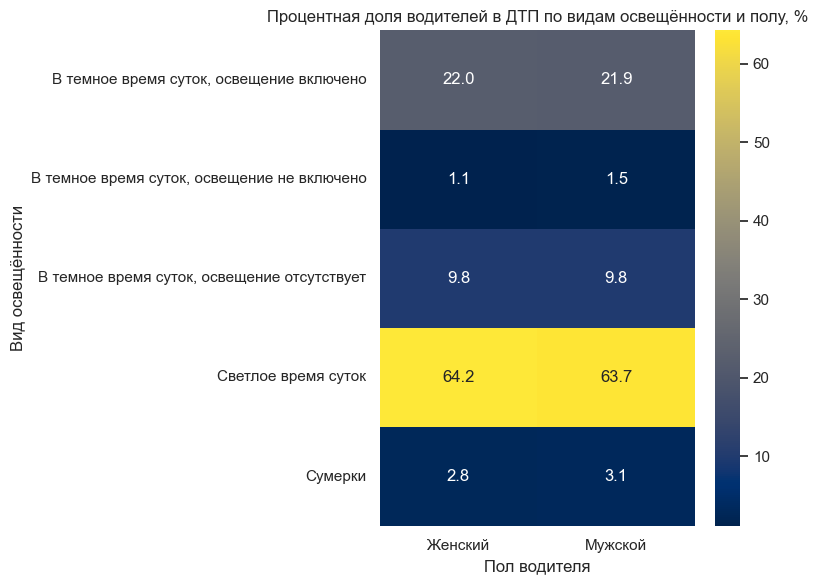

In [29]:
# 6. Визуализация: heatmap процентов
plt.figure(figsize=(8, 6))
sns.heatmap(
    percent_light_gender,
    annot=True,
    fmt='.1f',
    cmap='cividis'
)
plt.title('Процентная доля водителей в ДТП по видам освещённости и полу, %')
plt.xlabel('Пол водителя')
plt.ylabel('Вид освещённости')
plt.tight_layout()
plt.show()

<font color='#777778'>

**Промежуточный вывод по видам освещённости и полу участника**

- И у женщин, и у мужчин большинство ДТП происходит **в светлое время суток**: 64,2 % всех участниц и 63,7 % всех участников попадают в аварии именно днём.
- В тёмное время суток (включая варианты «освещение включено / не включено / отсутствует») приходится примерно треть ДТП для обоих полов: около 33 % у женщин и около 33 % у мужчин.
- Доля ДТП в сумерках невелика (2,8 % у женщин и 3,1 % у мужчин), а общая структура распределения по видам освещённости у мужчин и женщин очень похожа — заметных различий по полу в контексте освещённости не выявлено.

</font>

[Назад к содержанию](#2)

### **5.5**

### **Отличия аварий без пострадавших и с пострадавшими**

<font color='#777778'>
    
Первое предположение — попробовать решить задание, взяв ДТП, в которых `injured_count == 0`. Однако таких аварий в данных не оказалось.

Однако в данных есть столбец `health_status`, и на него можно опираться при оценке пострадавших. Также стоит обсудить с заказчиком, почему `injured_count` не согласуется с `health_status`.
</font>

In [30]:
# Флаг пострадавшего по health_status
drivers['is_injured'] = (drivers['health_status'] != 'Не пострадал').astype(int)
drivers['is_injured'].value_counts()

is_injured
0    9045
1    3980
Name: count, dtype: int64

In [31]:
# Список id ДТП с пострадавшими водителями
ids_injured = drivers.query('is_injured == 1')['id'].unique()
len(ids_injured), ids_injured[:10]

ERROR! Session/line number was not unique in database. History logging moved to new session 2


(3980,
 array([1983180, 2930931, 1984209, 1988400, 2498649, 1981028, 1986882,
        2562381, 1986043, 1980035]))

In [32]:
# Чистим признак road_conditions
kirov = kirov.copy()

kirov['road_conditions'] = kirov['road_conditions'].replace(
    "['Сухое', 'Отсутствие, плохая различимость горизонтальной разметки проезжей части']",
    "['Сухое', 'Разметка не различима']"
)

kirov['road_conditions'].value_counts().head()


road_conditions
['Сухое']                                          4135
['Сухое', 'Разметка не различима']                 1534
['Мокрое']                                         1342
['Обработанное противогололедными материалами']     886
['Заснеженное']                                     647
Name: count, dtype: int64

In [33]:
# Функция для построения сравнительных диаграмм

def plot_injured_vs_no_injured(df, ids_injured, columns, top_n=3):
    fig, axes = plt.subplots(
        nrows=len(columns),
        ncols=2,
        figsize=(15, 5 * len(columns))
    )
    plt.subplots_adjust(wspace=0.2, hspace=0.5)

    for i, column_name in enumerate(columns):
        # ДТП с пострадавшими
        df_injured = (
            df.query('id in @ids_injured')[column_name]
            .value_counts(normalize=True)
            .head(top_n)
            .reset_index()
        )
        df_injured.columns = [column_name, 'proportion']

        # ДТП без пострадавших
        df_no_injured = (
            df.query('id not in @ids_injured')[column_name]
            .value_counts(normalize=True)
            .head(top_n)
            .reset_index()
        )
        df_no_injured.columns = [column_name, 'proportion']

        # Круговая диаграмма: с пострадавшими
        df_injured.plot.pie(
            ax=axes[i, 0],
            y='proportion',
            labels=df_injured[column_name],
            autopct='%1.1f%%',
            legend=False
        )
        axes[i, 0].set_ylabel('')
        axes[i, 0].set_title(f'ДТП с пострадавшими: {column_name}')

        # Круговая диаграмма: без пострадавших
        df_no_injured.plot.pie(
            ax=axes[i, 1],
            y='proportion',
            labels=df_no_injured[column_name],
            autopct='%1.1f%%',
            legend=False
        )
        axes[i, 1].set_ylabel('')
        axes[i, 1].set_title(f'ДТП без пострадавших: {column_name}')

    plt.show()

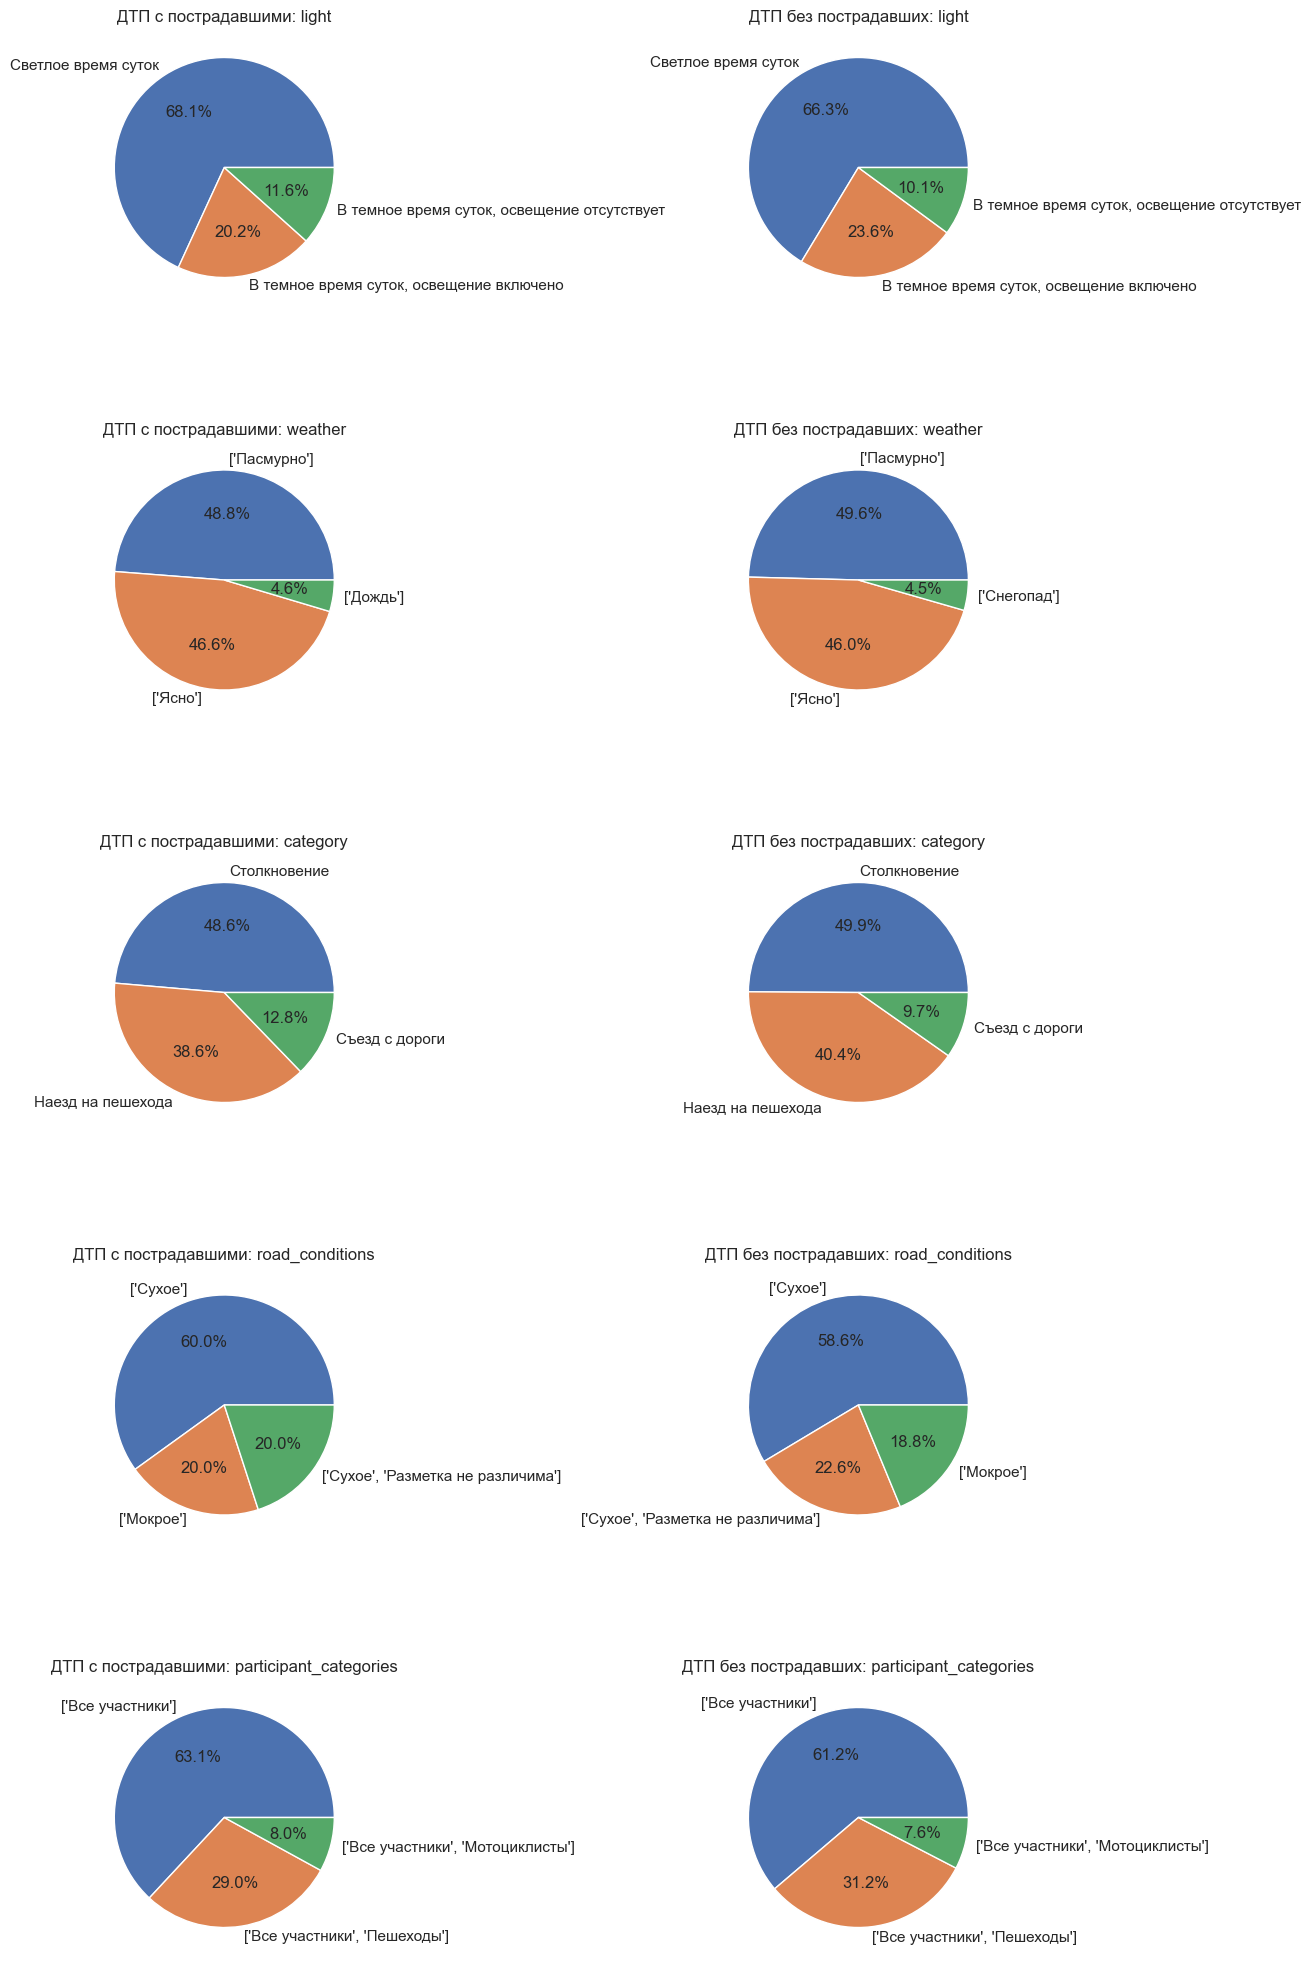

In [34]:
# Запуск визуализации для выбранных признаков
cols_for_compare = ['light', 'weather', 'category', 'road_conditions', 'participant_categories']
plot_injured_vs_no_injured(kirov, ids_injured, cols_for_compare, top_n=3)


<font color='#777778'>

**Промежуточные результаты**

- По признаку `is_injured` видно, что большинство ДТП с участием водителей проходит без пострадавших: около 9,0 тыс. случаев против 4,0 тыс. аварий, где по данным `health_status` зафиксированы пострадавшие.
- Распределение по `road_conditions` показывает, что основная масса аварий происходит на сухой дороге (в том числе при плохой различимости разметки). Мокрое покрытие встречается заметно реже, а заснеженные и обработанные противогололёдными материалами участки дороги дают ещё меньшую долю ДТП.

</font>

[Назад к содержанию](#2)

# **6**

---
## **Итоговый вывод и рекомендации**

### **6.1**

### **Общий обзор проделанной работы**

<div style="background-color: #AEBCC4; padding: 10px; border-radius: 4px;">
    
- В проекте были объединены таблицы `kirov` (ДТП) и `kirov_part` (участники), приведены к удобному виду названия столбцов, проверены типы данных и обработаны основные пропуски.  
- Проведён анализ числа участников ДТП: найдены типичные значения, редкие и потенциально аномальные случаи (включая ДТП с 30 участниками), а также изучена связь числа участников с числом пострадавших и схемой ДТП.  
- Построены срезы по категориям ДТП и погоде, а также по видам освещённости с раздельным учётом пола, после чего сравнивались ДТП с пострадавшими и без пострадавших по данным `health_status`. 
    </div>

[Назад к содержанию](#2)

### **6.2**

### **Ключевые выводы**

<div style="background-color: #AEBCC4; padding: 10px; border-radius: 4px;">
    
**Структура данных и число участников**

- `kirov` (14 517 строк) описывает сами аварии, `kirov_part` (31 235 строк) — участников; набор признаков позволяет анализировать ДТП как по событиям, так и по людям.  
- Чаще всего в ДТП участвуют 2–3 участника (медиана 2, верхний квартиль 3), значения выше 5 встречаются значительно реже; ДТП с 30 участниками выглядит как редкое и нетипичное наблюдение.  
- Между числом участников (`participants_count`) и числом пострадавших (`injured_count`) есть сильная положительная связь: рост числа участников сопровождается ростом числа пострадавших; разные схемы ДТП по-разному связаны с масштабом аварий.

**Категории ДТП, погода, освещённость и пострадавшие**

- Для основных категорий («Столкновение», «Наезд на пешехода», «Съезд с дороги», «Опрокидывание», «Падение пассажира») большинство аварий приходится на погоду «Пасмурно» и «Ясно», тогда как экстремальные условия и сложные сочетания с осадками встречаются заметно реже.  
- В разбивке по освещённости мужчины и женщины демонстрируют схожую картину: около двух третей ДТП происходит днём, около трети — в тёмное время суток, доля сумерек мала, выраженных различий по полу не выявлено.  
- По `health_status` видно, что значимая доля ДТП проходит без пострадавших, но в части аварий фиксируются пострадавшие; основная масса ДТП происходит на сухой дороге (в том числе при плохой различимости разметки), а мокрое, заснеженное и обработанное покрытие встречаются реже.  
- Обнаружено несоответствие между `injured_count` и индивидуальными статусами `health_status`: в некоторых случаях агрегированное число пострадавших не отражает фактическое состояние участников.
    </div>

[Назад к содержанию](#2)

### **6.3**

### **Рекомендации для заказчика**

<div style="background-color: #AEBCC4; padding: 10px; border-radius: 4px;">
    
**По данным и качеству учёта**

- Уточнить причины расхождения `injured_count` и `health_status` и скорректировать правила заполнения, чтобы агрегированное число пострадавших соответствовало статусам участников.  
- Отдельно проверить редкие и нетипичные случаи (например, ДТП с 30 участниками) по первичным источникам, чтобы исключить ошибки ввода или особенностей агрегирования.  

**По повышению безопасности**

- Сфокусировать меры профилактики не только на экстремальной погоде, но и на массовых сценариях (пасмурная и ясная погода днём), особенно для столкновений и наездов на пешеходов.  
- На участках с сухим покрытием и плохо различимой разметкой рассмотреть инфраструктурные улучшения: обновление разметки, освещения, знаков, меры по снижению скорости.  
- Учитывая сильную связь числа участников и числа пострадавших, дополнительно проанализировать места и схемы, где чаще возникают ДТП с большим числом участников (перекрёстки, участки с высокой интенсивностью движения), и приоритизировать там меры по повышению безопасности.
    </div>

[Назад к содержанию](#2)